# Task 2 — Fashion Season Classification EDA

This notebook investigates the supplied training data for Task 2. The input is a fashion image and the target is `season`. It checks data quality, measures class imbalance, audits the images, shows representative samples, and establishes a majority-class baseline. Generated evidence is saved under `task2/results/eda/`.

## 1. Imports, reproducibility, and paths

The dataset remains outside `task2/`. This notebook reads it through the paths in `task2/config/eda_config.json` and never modifies the source files.

In [1]:
from collections import Counter
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
SEASON_ORDER = ["Spring", "Summer", "Fall", "Winter"]

def find_task2_dir(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if candidate.name == "task2" and (candidate / "pyproject.toml").exists():
            return candidate
        sibling = candidate / "task2"
        if (sibling / "pyproject.toml").exists():
            return sibling
    raise FileNotFoundError("Could not locate the project task2 directory.")

TASK2_DIR = find_task2_dir(Path.cwd().resolve())
with (TASK2_DIR / "config/eda_config.json").open(encoding="utf-8") as config_file:
    CONFIG = json.load(config_file)

def resolve_from_task2(relative_path: str) -> Path:
    return (TASK2_DIR / relative_path).resolve()

TRAIN_CSV = resolve_from_task2(CONFIG["paths"]["train_csv"])
TRAIN_IMAGES = resolve_from_task2(CONFIG["paths"]["train_images"])
TEST_CSV = resolve_from_task2(CONFIG["paths"]["test_csv"])
TEST_IMAGES = resolve_from_task2(CONFIG["paths"]["test_images"])
RESULTS_DIR = TASK2_DIR / CONFIG["paths"]["results"] / "eda"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
print(f"Task 2 directory: {TASK2_DIR}")
print(f"Training CSV: {TRAIN_CSV}")
print(f"Training images: {TRAIN_IMAGES}")
print(f"Test CSV: {TEST_CSV}")
print(f"Test images: {TEST_IMAGES}")
print(f"EDA output: {RESULTS_DIR}")

Task 2 directory: /Users/mthnhng/Document/RMIT Master in AI/Sem-2-2026/Machine_Learning/assignment-2/COSC2753-Project/task2
Training CSV: /Users/mthnhng/Document/RMIT Master in AI/Sem-2-2026/Machine_Learning/assignment-2/COSC2753-Project/FashionDataset/train/styles_train.csv
Training images: /Users/mthnhng/Document/RMIT Master in AI/Sem-2-2026/Machine_Learning/assignment-2/COSC2753-Project/FashionDataset/train/images_train
Test CSV: /Users/mthnhng/Document/RMIT Master in AI/Sem-2-2026/Machine_Learning/assignment-2/COSC2753-Project/FashionDataset/test/styles_prediction.csv
Test images: /Users/mthnhng/Document/RMIT Master in AI/Sem-2-2026/Machine_Learning/assignment-2/COSC2753-Project/FashionDataset/test/images_test
EDA output: /Users/mthnhng/Document/RMIT Master in AI/Sem-2-2026/Machine_Learning/assignment-2/COSC2753-Project/task2/results/eda


## 2. Load metadata and audit row/image alignment

Empty trailing columns are a formatting artefact in the supplied CSV. Rows without a target or image cannot train an image classifier, so they are identified and excluded from the usable sample without changing the original CSV.

In [2]:
raw_metadata = pd.read_csv(TRAIN_CSV, dtype={"id": "string"})
unnamed_columns = [column for column in raw_metadata.columns if column.startswith("Unnamed:")]
metadata = raw_metadata.drop(columns=unnamed_columns).copy()
metadata["id"] = metadata["id"].str.strip()
metadata["season"] = metadata["season"].astype("string").str.strip()
metadata.loc[metadata["season"] == "", "season"] = pd.NA
metadata["image_path"] = metadata["id"].map(lambda image_id: TRAIN_IMAGES / f"{image_id}.jpg")
metadata["image_exists"] = metadata["image_path"].map(Path.exists)

csv_ids = set(metadata["id"].dropna())
image_files = sorted(TRAIN_IMAGES.glob("*.jpg"))
image_ids = {path.stem for path in image_files}
missing_image_ids = sorted(csv_ids - image_ids, key=int)
extra_image_ids = sorted(image_ids - csv_ids, key=int)
missing_season_ids = metadata.loc[metadata["season"].isna(), "id"].tolist()
valid_metadata = metadata.loc[metadata["season"].notna() & metadata["image_exists"]].copy()

expected_prediction_columns = ["id", "gender", "articleType", "season", "usage"]
prediction_template = pd.read_csv(TEST_CSV, dtype={"id": "string"})
prediction_template["id"] = prediction_template["id"].str.strip()
test_image_files = sorted(TEST_IMAGES.glob("*.jpg"))
test_csv_ids = set(prediction_template["id"].dropna())
test_image_ids = {path.stem for path in test_image_files}
test_ids_missing_image = sorted(test_csv_ids - test_image_ids, key=int)
test_images_missing_csv_row = sorted(test_image_ids - test_csv_ids, key=int)

unexpected_seasons = sorted(set(valid_metadata["season"]) - set(SEASON_ORDER))
assert not unexpected_seasons, f"Unexpected season labels: {unexpected_seasons}"
assert list(prediction_template.columns) == expected_prediction_columns, "Prediction CSV schema changed."
assert not test_ids_missing_image, "Some test CSV IDs have no image."
assert not test_images_missing_csv_row, "Some test images have no prediction row."

quality_summary = {
    "raw_csv_rows": int(len(raw_metadata)),
    "empty_trailing_columns_removed": unnamed_columns,
    "unique_csv_ids": int(metadata["id"].nunique()),
    "duplicate_csv_ids": int(metadata["id"].duplicated().sum()),
    "training_image_files": int(len(image_files)),
    "rows_missing_season": int(metadata["season"].isna().sum()),
    "missing_season_ids": missing_season_ids,
    "csv_rows_missing_image": int(len(missing_image_ids)),
    "missing_image_ids": missing_image_ids,
    "images_missing_csv_row": int(len(extra_image_ids)),
    "extra_image_ids": extra_image_ids,
    "usable_task2_rows": int(len(valid_metadata)),
    "test_csv_rows": int(len(prediction_template)),
    "test_image_files": int(len(test_image_files)),
    "test_unique_csv_ids": int(prediction_template["id"].nunique()),
    "test_ids_missing_image": test_ids_missing_image,
    "test_images_missing_csv_row": test_images_missing_csv_row,
    "prediction_columns": list(prediction_template.columns),
    "prediction_schema_matches_assignment": bool(list(prediction_template.columns) == expected_prediction_columns),
}

with (RESULTS_DIR / "data_quality_summary.json").open("w", encoding="utf-8") as output_file:
    json.dump(quality_summary, output_file, indent=2)

pd.Series(quality_summary, name="value")

raw_csv_rows                                                                        38617
empty_trailing_columns_removed                                 [Unnamed: 10, Unnamed: 11]
unique_csv_ids                                                                      38617
duplicate_csv_ids                                                                       0
training_image_files                                                                38612
rows_missing_season                                                                    20
missing_season_ids                      [5354, 5355, 5360, 5361, 5365, 5368, 5370, 537...
csv_rows_missing_image                                                                  5
missing_image_ids                                     [12347, 39401, 39403, 39410, 39425]
images_missing_csv_row                                                                  0
extra_image_ids                                                                        []
usable_tas

## 3. Target-class distribution

The class counts determine the baseline, split strategy, model-selection metric, and class-weight search.

In [3]:
season_counts = valid_metadata["season"].value_counts().reindex(SEASON_ORDER)
season_distribution = pd.DataFrame({
    "season": SEASON_ORDER,
    "count": season_counts.to_numpy(dtype=int),
})
season_distribution["percentage"] = (
    100 * season_distribution["count"] / season_distribution["count"].sum()
).round(3)
season_distribution.to_csv(RESULTS_DIR / "season_class_distribution.csv", index=False)
season_distribution

,season,count,percentage
0,Spring,1566,4.058
1,Summer,19135,49.583
2,Fall,10512,27.239
3,Winter,7379,19.121


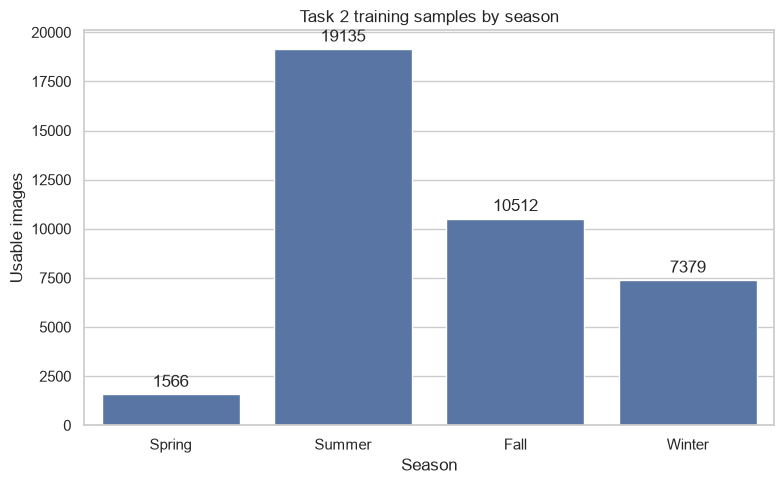

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=season_distribution, x="season", y="count", order=SEASON_ORDER, ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)
ax.set(title="Task 2 training samples by season", xlabel="Season", ylabel="Usable images")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "season_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

## 4. Image integrity and dimensions

Every supplied training image is opened and verified. Image dimensions are recorded so later preprocessing can use one justified input size.

In [5]:
size_counts = Counter()
unreadable_images = []

for image_path in image_files:
    try:
        with Image.open(image_path) as image:
            size_counts[image.size] += 1
            image.verify()
    except Exception as error:
        unreadable_images.append({"id": image_path.stem, "path": str(image_path), "error": str(error)})

image_size_distribution = pd.DataFrame([
    {"width": width, "height": height, "count": count}
    for (width, height), count in size_counts.most_common()
])
unreadable_table = pd.DataFrame(unreadable_images, columns=["id", "path", "error"])
image_size_distribution.to_csv(RESULTS_DIR / "image_size_distribution.csv", index=False)
unreadable_table.to_csv(RESULTS_DIR / "unreadable_images.csv", index=False)

print(f"Distinct image sizes: {len(image_size_distribution)}")
print(f"Unreadable images: {len(unreadable_table)}")
image_size_distribution.head(10)

Distinct image sizes: 6
Unreadable images: 0


,width,height,count
0,60,80,38595
1,53,80,8
2,60,60,5
3,60,77,2
4,60,76,1
5,60,75,1


## 5. Reproducible visual sample

Four examples are sampled from each season with a fixed seed. This checks whether the labels appear visually learnable and highlights ambiguity that should be discussed in the report.

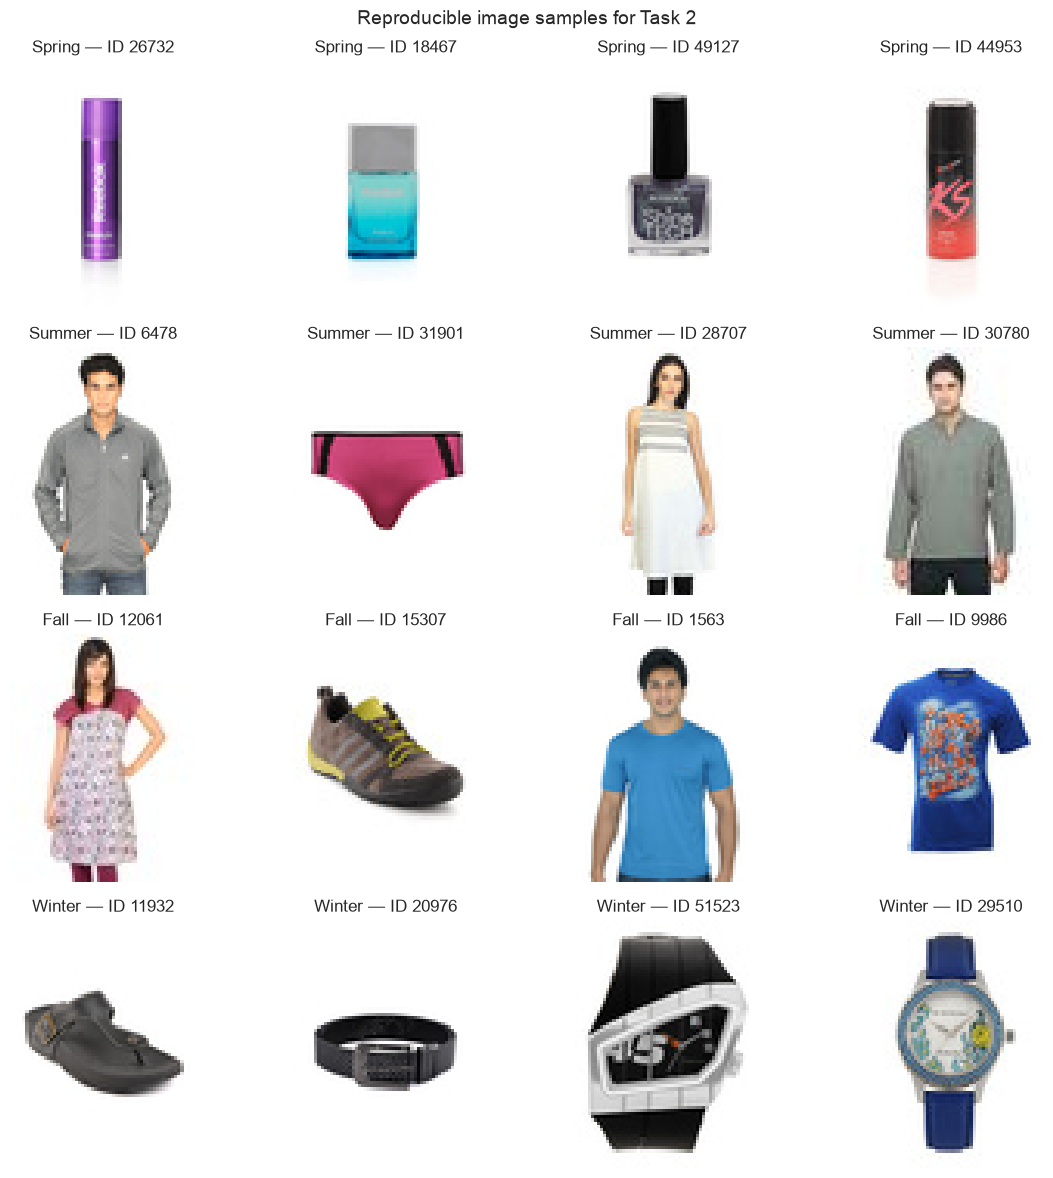

In [6]:
samples_per_class = 4
fig, axes = plt.subplots(len(SEASON_ORDER), samples_per_class, figsize=(12, 12))

for row_index, season in enumerate(SEASON_ORDER):
    samples = valid_metadata.loc[valid_metadata["season"] == season].sample(
        n=samples_per_class, random_state=RANDOM_SEED
    )
    for column_index, (_, sample) in enumerate(samples.iterrows()):
        axis = axes[row_index, column_index]
        with Image.open(sample["image_path"]) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(f"{season} — ID {sample['id']}")
        axis.axis("off")

fig.suptitle("Reproducible image samples for Task 2", fontsize=14)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "season_samples.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Majority-class baseline

A stratified 80/20 split establishes the performance obtained by always predicting the most frequent class. The split uses the fixed Task 2 seed and mirrors the split policy planned for model development.

In [7]:
labels = valid_metadata["season"].to_numpy()
indices = np.arange(len(labels))
development_indices, holdout_indices = train_test_split(
    indices,
    test_size=CONFIG["data"]["holdout_ratio"],
    random_state=CONFIG["data"]["random_seed"],
    stratify=labels,
)

dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(np.zeros((len(development_indices), 1)), labels[development_indices])
baseline_predictions = dummy_model.predict(np.zeros((len(holdout_indices), 1)))

baseline_metrics = {
    "strategy": "most_frequent",
    "predicted_class": str(dummy_model.classes_[np.argmax(dummy_model.class_prior_)]),
    "development_rows": int(len(development_indices)),
    "holdout_rows": int(len(holdout_indices)),
    "accuracy": float(accuracy_score(labels[holdout_indices], baseline_predictions)),
    "macro_f1": float(f1_score(labels[holdout_indices], baseline_predictions, average="macro", zero_division=0)),
}
with (RESULTS_DIR / "majority_baseline_metrics.json").open("w", encoding="utf-8") as output_file:
    json.dump(baseline_metrics, output_file, indent=2)
baseline_metrics

{'strategy': 'most_frequent',
 'predicted_class': 'Summer',
 'development_rows': 30873,
 'holdout_rows': 7719,
 'accuracy': 0.49578961005311567,
 'macro_f1': 0.16572839078468735}

## 7. Findings and modelling implications

The final cell writes a concise evidence summary that can be used when drafting the assignment report.

In [8]:
distribution_lines = "\n".join(
    f"- {row.season}: {row.count:,} images ({row.percentage:.3f}%)"
    for row in season_distribution.itertuples(index=False)
)
most_common_size = image_size_distribution.iloc[0] if not image_size_distribution.empty else None
size_statement = (
    f"{int(most_common_size['width'])}x{int(most_common_size['height'])} "
    f"({int(most_common_size['count']):,} images)"
    if most_common_size is not None else "unavailable"
)

findings = f"""# Task 2 EDA findings

## Data quality

- The supplied metadata contains {quality_summary['raw_csv_rows']:,} rows and the image directory contains {quality_summary['training_image_files']:,} JPEG files.
- {quality_summary['rows_missing_season']:,} rows have no season label and cannot be supervised training examples.
- {quality_summary['csv_rows_missing_image']:,} metadata rows have no matching image.
- {quality_summary['usable_task2_rows']:,} rows have both a valid season and a matching image.
- The prediction template has {quality_summary['test_csv_rows']:,} rows matching {quality_summary['test_image_files']:,} test images, with the required column order.
- {len(unreadable_table):,} supplied images failed Pillow verification.
- The most common image size is {size_statement}.

## Class distribution

{distribution_lines}

The majority-class baseline predicts {baseline_metrics['predicted_class']} and obtains {baseline_metrics['accuracy']:.4f} accuracy but only {baseline_metrics['macro_f1']:.4f} macro-F1. The gap occurs because the baseline never recognises the minority seasons.

## Modelling implications

- Use stratified development/holdout splitting and stratified cross-validation so every season is represented proportionally.
- Select GridSearchCV candidates by macro-F1, then report accuracy and weighted-F1 as supporting metrics.
- Tune Task2CNN channel widths, dropout, and learning rate, and use early stopping to control overfitting.
- Report per-class recall and a confusion matrix; overall accuracy can hide failure on Spring.
- Apply one deterministic image-resizing and normalization policy to training, holdout, and test images.
- Season can be a merchandising label rather than an unambiguous visual property, so inspect errors and discuss visually plausible cross-season confusion.
"""

(RESULTS_DIR / "eda_findings.md").write_text(findings, encoding="utf-8")
print(findings)

# Task 2 EDA findings

## Data quality

- The supplied metadata contains 38,617 rows and the image directory contains 38,612 JPEG files.
- 20 rows have no season label and cannot be supervised training examples.
- 5 metadata rows have no matching image.
- 38,592 rows have both a valid season and a matching image.
- The prediction template has 5,829 rows matching 5,829 test images, with the required column order.
- 0 supplied images failed Pillow verification.
- The most common image size is 60x80 (38,595 images).

## Class distribution

- Spring: 1,566 images (4.058%)
- Summer: 19,135 images (49.583%)
- Fall: 10,512 images (27.239%)
- Winter: 7,379 images (19.121%)

The majority-class baseline predicts Summer and obtains 0.4958 accuracy but only 0.1657 macro-F1. The gap occurs because the baseline never recognises the minority seasons.

## Modelling implications

- Use stratified development/holdout splitting and stratified cross-validation so every season is represented proportionally